In [1]:
!pip install git+https://github.com/mo-karbalaee/NEUROSEG.git

  Cloning https://github.com/mo-karbalaee/NEUROSEG.git to /tmp/pip-req-build-sryks95c
  Running command git clone --filter=blob:none --quiet https://github.com/mo-karbalaee/NEUROSEG.git /tmp/pip-req-build-sryks95c
  Resolved https://github.com/mo-karbalaee/NEUROSEG.git to commit 5e6cb8d579ce37ba23729b4ecaf6745ea6dcff57
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.3/203.3 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.1/246.1 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 98.5 M

In [2]:
from neuroseg.pipeline import run
from neuroseg.models.hypothesis import Hypothesis
from neuroseg.models.mode import Mode
import gc
import torch
import os

In [3]:
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

try:
    run(
        data_dir="/kaggle/input/datasets/mokarbalaee/neurofinder-mini/neurofinder.00.00/neurofinder.00.00",
        output_dir="/kaggle/working/output",
        mode=Mode.TRAINING,
        hypothesis=Hypothesis.H1,
        config={
            "labeled_data_dir": "/kaggle/input/datasets/mokarbalaee/neurofinder-mini/neurofinder.00.00/neurofinder.00.00",
            "pretrain_epochs": 50,
            "finetune_epochs": 50,
            "img_size": 128,
            "batch_size": 4,
            "seq_len": 5,
            "num_workers": 2,
            "labeled_fractions": [0.01, 0.05, 0.1, 1.0],
        },
    )
except Exception as e:
    gc.collect()
    torch.cuda.empty_cache()
    raise


Found 6 file(s) in /kaggle/input/datasets/mokarbalaee/neurofinder-mini/neurofinder.00.00/neurofinder.00.00
[H1] device=cuda | data=/kaggle/input/datasets/mokarbalaee/neurofinder-mini/neurofinder.00.00/neurofinder.00.00 | output=/kaggle/working/output


2026/06/28 19:23:25 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/28 19:23:25 INFO mlflow.store.db.utils: Updating database tables
2026/06/28 19:23:27 INFO mlflow.tracking.fluent: Experiment with name 'neuroseg-H1-pretrain' does not exist. Creating a new experiment.
[pretrain] Epoch 49: 100%|██████████| 136/136 [01:22<00:00,  1.64it/s, jepa=0.0220, recon=0.0008]


Pretrained checkpoint: /kaggle/working/output/jepa_pretrained_h1_9f2de9f870c04ef1a54ab96d3aceb397.pt


2026/06/28 20:35:16 INFO mlflow.tracking.fluent: Experiment with name 'neuroseg-H1-finetune' does not exist. Creating a new experiment.
[supervised_baseline] f=1.0 ep=49: 100%|██████████| 136/136 [00:13<00:00, 10.18it/s]


[H1] Done.


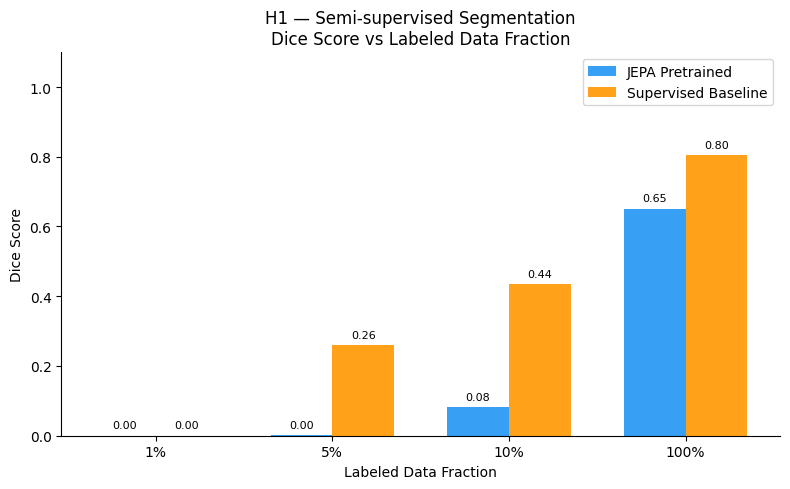

In [5]:
import mlflow
import matplotlib.pyplot as plt
import numpy as np

mlflow.set_tracking_uri("sqlite:///mlflow.db")
client = mlflow.tracking.MlflowClient()

exp = client.get_experiment_by_name("neuroseg-H1-finetune")
runs = client.search_runs([exp.experiment_id], order_by=["attribute.start_time ASC"])

results = {"finetune": {}, "supervised_baseline": {}}
for run in runs:
    mode = run.data.tags.get("mode")
    frac = run.data.tags.get("labeled_fraction")
    dice = run.data.metrics.get("val/dice")
    if mode in results and frac and dice is not None:
        results[mode][float(frac)] = dice

fractions = sorted(set(list(results["finetune"]) + list(results["supervised_baseline"])))
x = np.arange(len(fractions))
w = 0.35
jepa_vals = [results["finetune"].get(f, 0.0) for f in fractions]
base_vals  = [results["supervised_baseline"].get(f, 0.0) for f in fractions]

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, jepa_vals, w, label="JEPA Pretrained",     color="#2196F3", alpha=0.9)
b2 = ax.bar(x + w/2, base_vals,  w, label="Supervised Baseline", color="#FF9800", alpha=0.9)
for bar in (*b1, *b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.015, f"{h:.2f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([f"{int(f*100)}%" for f in fractions])
ax.set_xlabel("Labeled Data Fraction")
ax.set_ylabel("Dice Score")
ax.set_title("H1 — Semi-supervised Segmentation\nDice Score vs Labeled Data Fraction")
ax.set_ylim(0, 1.1)
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("h1_dice_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
